Data shape: (833, 4)

Columns: ['job title', 'company name', 'location', 'skills']

First 5 rows:
                           job title company name  \
0                AI Academy Vodafone     Vodafone   
1            Senior Business Analyst        dopay   
2  Junior Solution Architect  RedHat          NaN   
3                Intern AI Technical      Tamatem   
4                   SCC V&V Engineer       Alstom   

                                           location  \
0  Egypt                                    , Egypt   
1  Egypt                                    , Cairo   
2  Egypt                                    , Cairo   
3                                             Egypt   
4  Egypt                                    , Egypt   

                                   skills  
0                           Not Mentioned  
1  Business Intelligence & Data Analytics  
2                           Not Mentioned  
3             Arabic AI & NLP Engineering  
4                           Not 

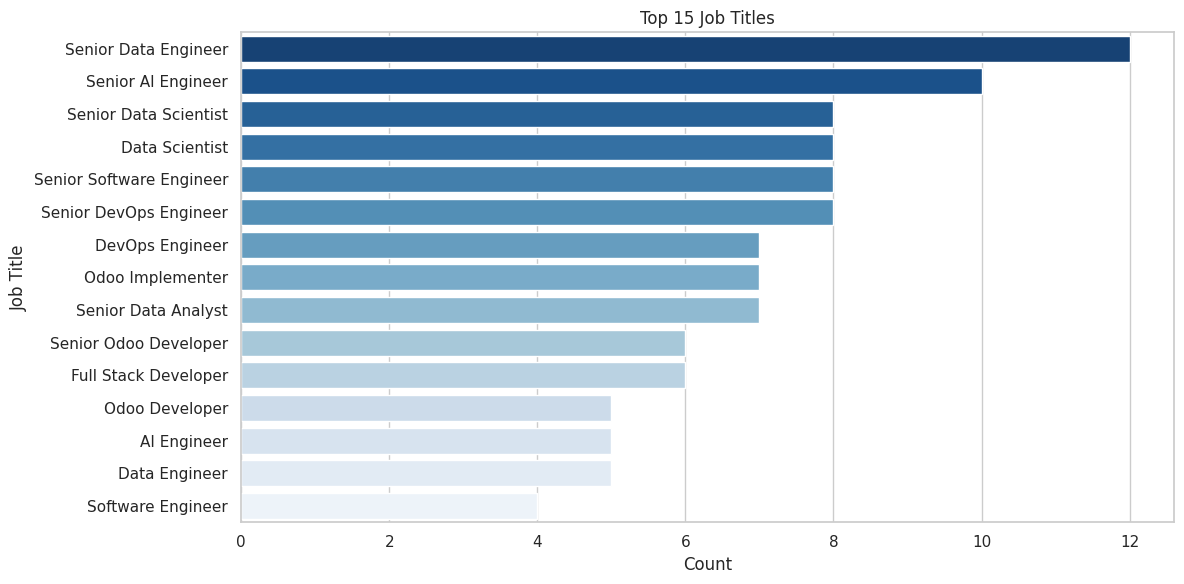

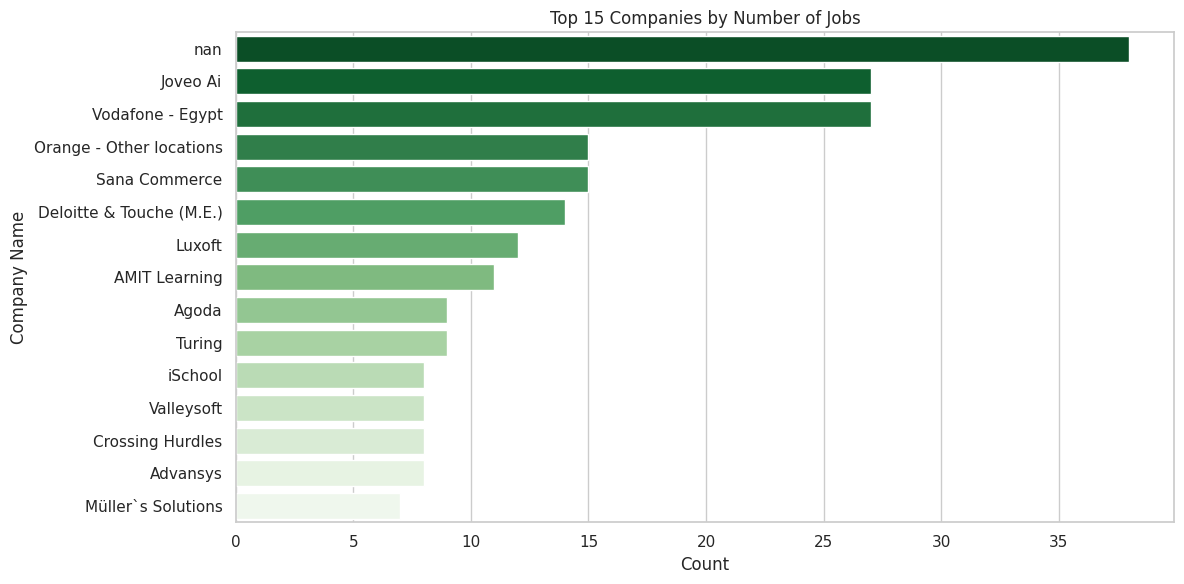

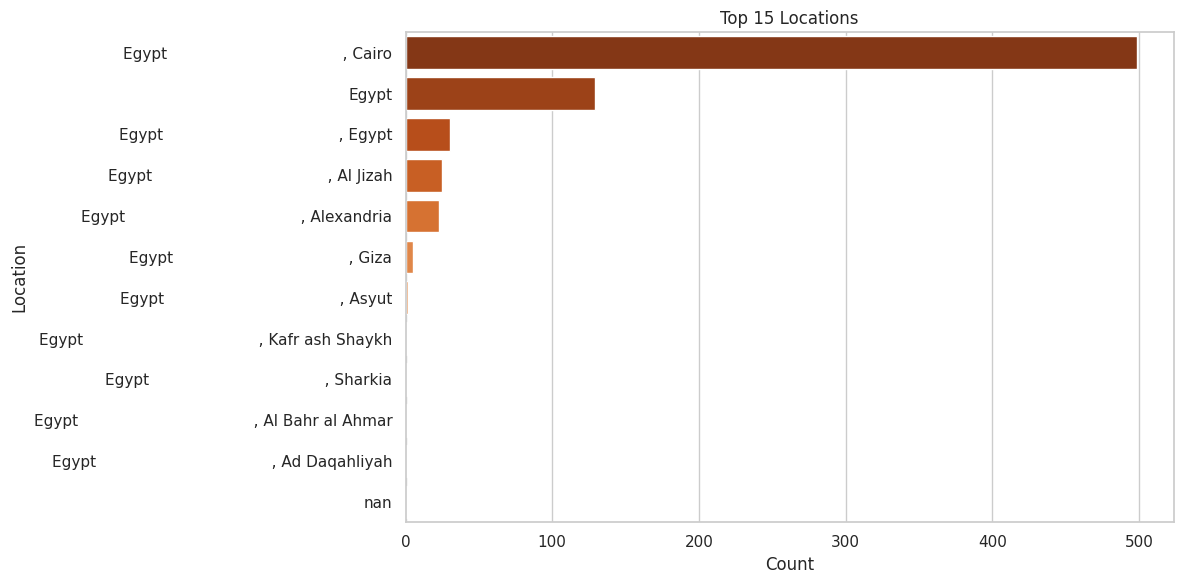

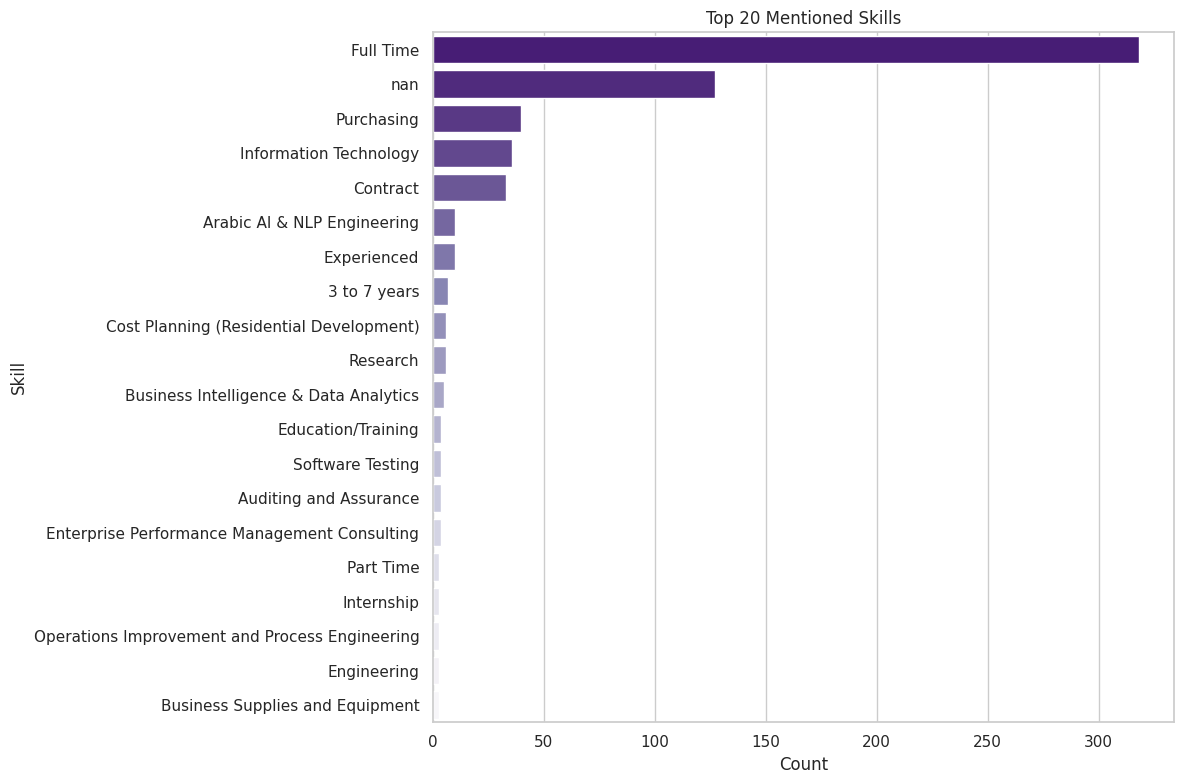

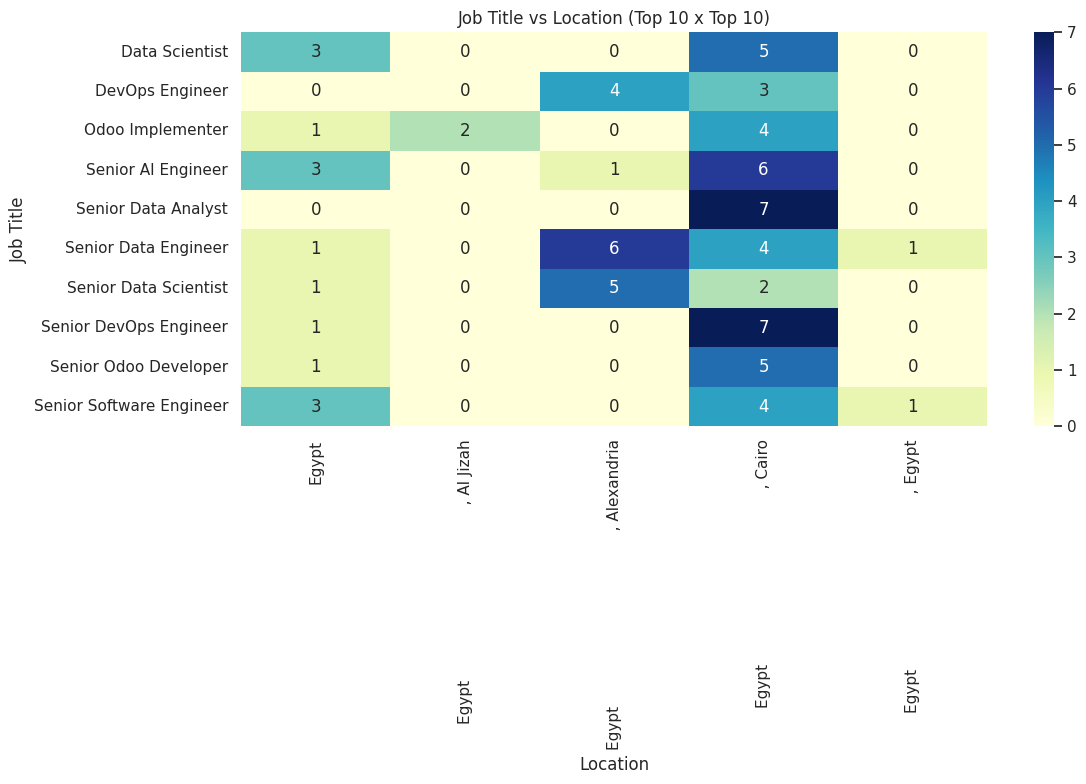


=== Quick EDA Summary ===
Most common job titles:
job title
Senior Data Engineer        12
Senior AI Engineer          10
Senior Data Scientist        8
Data Scientist               8
Senior Software Engineer     8
Name: count, dtype: int64

Most active companies:
company name
nan                         38
Joveo Ai                    27
Vodafone - Egypt            27
Orange - Other locations    15
Sana Commerce               15
Name: count, dtype: int64

Most frequent locations:
location
Egypt                                    , Cairo         499
Egypt                                                    129
Egypt                                    , Egypt          30
Egypt                                    , Al Jizah       25
Egypt                                    , Alexandria     23
Name: count, dtype: int64


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# -----------------------------
# 1. Basic setup
# -----------------------------
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# -----------------------------
# 2. Load data
# -----------------------------
# Paste your CSV URL/path inside read_csv()
df = pd.read_csv("/kaggle/input/datasets/akramehab/tanqeeb-egypt-jobs-dataset-web-scraping-csv/tanqeeb_jobs.csv")
df = df.drop_duplicates()

# Make column names uniform (lowercase + stripped spaces)
df.columns = [col.strip().lower() for col in df.columns]

# -----------------------------
# 3. Exclude link columns
# -----------------------------
# We remove columns that contain links (for your case: "detail link")
link_like_cols = [c for c in df.columns if "link" in c or "url" in c or "http" in c]
df = df.drop(columns=link_like_cols, errors="ignore")

# -----------------------------
# 4. Initial inspection
# -----------------------------
print("Data shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isna().sum())

print("\nDuplicate rows count:", df.duplicated().sum())

# -----------------------------
# 5. Data cleaning for text fields
# -----------------------------
# Convert all object columns to string, strip spaces, and normalize placeholders
obj_cols = df.select_dtypes(include="object").columns
for col in obj_cols:
    df[col] = df[col].astype(str).str.strip()
    # Normalize common placeholder values as missing
    df[col] = df[col].replace(
        {"N/A": np.nan, "n/a": np.nan, "Not Mentioned": np.nan, "not mentioned": np.nan, "": np.nan}
    )

# Optional: drop exact duplicates after cleaning
df = df.drop_duplicates()

print("\nMissing values after placeholder normalization:")
print(df.isna().sum())

# -----------------------------
# 6. Univariate EDA
# -----------------------------
# Top job titles
if "job title" in df.columns:
    top_titles = df["job title"].value_counts().head(15)
    plt.figure()
    sns.barplot(x=top_titles.values, y=top_titles.index, palette="Blues_r")
    plt.title("Top 15 Job Titles")
    plt.xlabel("Count")
    plt.ylabel("Job Title")
    plt.tight_layout()
    plt.show()

# Top companies
if "company name" in df.columns:
    top_companies = df["company name"].value_counts().head(15)
    plt.figure()
    sns.barplot(x=top_companies.values, y=top_companies.index, palette="Greens_r")
    plt.title("Top 15 Companies by Number of Jobs")
    plt.xlabel("Count")
    plt.ylabel("Company Name")
    plt.tight_layout()
    plt.show()

# Top locations
if "location" in df.columns:
    top_locations = df["location"].value_counts().head(15)
    plt.figure()
    sns.barplot(x=top_locations.values, y=top_locations.index, palette="Oranges_r")
    plt.title("Top 15 Locations")
    plt.xlabel("Count")
    plt.ylabel("Location")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 7. Skills analysis
# -----------------------------
if "skills" in df.columns:
    # Split skills by common separators and explode into one skill per row
    # This helps us count most frequent individual skills
    skills_series = (
        df["skills"]
        .dropna()
        .astype(str)
        .str.replace("|", ",", regex=False)
        .str.replace(";", ",", regex=False)
        .str.split(",")
    )

    exploded_skills = skills_series.explode().str.strip()
    exploded_skills = exploded_skills[exploded_skills.notna() & (exploded_skills != "")]

    top_skills = exploded_skills.value_counts().head(20)

    plt.figure(figsize=(12, 8))
    sns.barplot(x=top_skills.values, y=top_skills.index, palette="Purples_r")
    plt.title("Top 20 Mentioned Skills")
    plt.xlabel("Count")
    plt.ylabel("Skill")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 8. Simple cross-analysis
# -----------------------------
# Top job titles by top locations (heatmap)
if {"job title", "location"}.issubset(df.columns):
    top_loc_names = df["location"].value_counts().head(10).index
    top_job_names = df["job title"].value_counts().head(10).index

    subset = df[df["location"].isin(top_loc_names) & df["job title"].isin(top_job_names)]
    pivot = pd.crosstab(subset["job title"], subset["location"])

    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot, annot=True, fmt="d", cmap="YlGnBu")
    plt.title("Job Title vs Location (Top 10 x Top 10)")
    plt.xlabel("Location")
    plt.ylabel("Job Title")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 9. EDA conclusion prints
# -----------------------------
print("\n=== Quick EDA Summary ===")
if "job title" in df.columns:
    print("Most common job titles:")
    print(df["job title"].value_counts().head(5))
if "company name" in df.columns:
    print("\nMost active companies:")
    print(df["company name"].value_counts().head(5))
if "location" in df.columns:
    print("\nMost frequent locations:")
    print(df["location"].value_counts().head(5))